In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load cleaned dataset
df = pd.read_csv("C:/Users/ASUS/Desktop/Crime Analytics/Dataset/cleaned_crime_data.csv")

# Display first rows
df.head()

,UNNAMED:_0,STATE/UT,YEAR,POPULATION,MALES,FEMALES,MALES(PER_100K),FEMALES(PER_100K),TOTAL_IPC_CRIMES,TOTAL_IPC_CRIMES(PER_100K),...,RAPE,RAPE(PER_100K),RIOTS,RIOTS(PER_100K),ROBBERY,ROBBERY(PER_100K),THEFT,THEFT(PER_100K),OTHER_IPC_CRIMES,OTHER_IPC_CRIMES(PER_100K)
0,0,A&N Islands,2001,356,193,163,54213.48315,45786.51685,1316,369662.9213,...,6,1685.393258,26,7303.370787,8,2247.191011,130,36516.85393,646,181460.67420
1,1,Andhra Pradesh,2001,76210,38527,37683,50553.73311,49446.26689,260178,341396.1422,...,1742,2285.789267,6002,7875.606876,1258,1650.702008,33502,43960.11022,68688,90129.90421
2,2,Arunachal Pradesh,2001,1098,580,518,52823.31512,47176.68488,4684,426593.8069,...,66,6010.928962,48,4371.584699,168,15300.546450,886,80692.16758,1236,112568.30600
3,3,Assam,2001,26656,13777,12878,51684.42377,48311.82473,73754,276688.1753,...,1634,6129.951981,5906,22156.362550,1374,5154.561825,10734,40268.60744,18630,69890.45618
4,4,Bihar,2001,82999,43244,39755,52101.83255,47898.16745,176864,213091.7240,...,1776,2139.784817,17212,20737.599250,4406,5308.497693,19402,23376.18526,73334,88355.28139


In [3]:
print("Years available:", sorted(df["YEAR"].unique()))
print("Total States:", df["STATE/UT"].nunique())

Years available: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]
Total States: 35


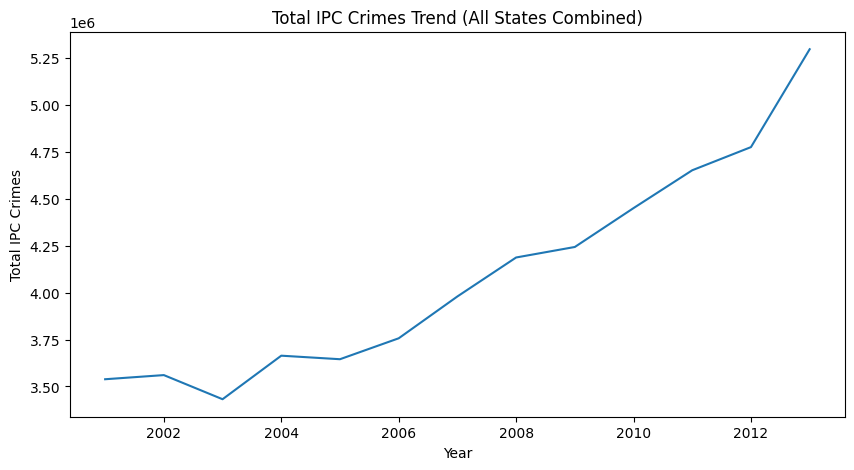

In [4]:
# Group by year and sum total IPC crimes
yearly_total = df.groupby("YEAR")["TOTAL_IPC_CRIMES"].sum()

# Plot trend
plt.figure(figsize=(10,5))
plt.plot(yearly_total.index, yearly_total.values)
plt.title("Total IPC Crimes Trend (All States Combined)")
plt.xlabel("Year")
plt.ylabel("Total IPC Crimes")
plt.show()

In [5]:
latest_year = df["YEAR"].max()

latest_df = df[df["YEAR"] == latest_year]

top_states = latest_df.sort_values(
    by="TOTAL_IPC_CRIMES",
    ascending=False
).head(5)

top_states[["STATE/UT", "TOTAL_IPC_CRIMES"]]

,STATE/UT,TOTAL_IPC_CRIMES
440,Maharashtra,468770
439,Madhya Pradesh,454906
452,Uttar Pradesh,452890
421,Andhra Pradesh,436030
450,Tamil Nadu,407158


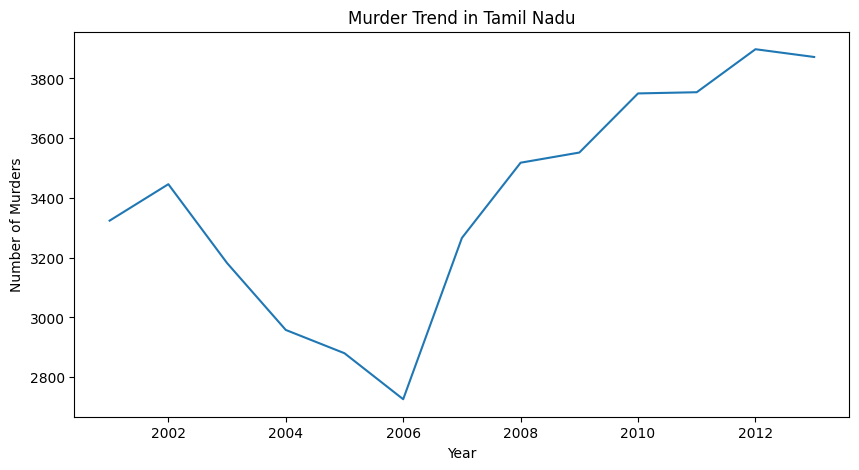

In [6]:
state = "Tamil Nadu"  # you can change state here

state_df = df[df["STATE/UT"] == state]

plt.figure(figsize=(10,5))
plt.plot(state_df["YEAR"], state_df["MURDER"])
plt.title(f"Murder Trend in {state}")
plt.xlabel("Year")
plt.ylabel("Number of Murders")
plt.show()

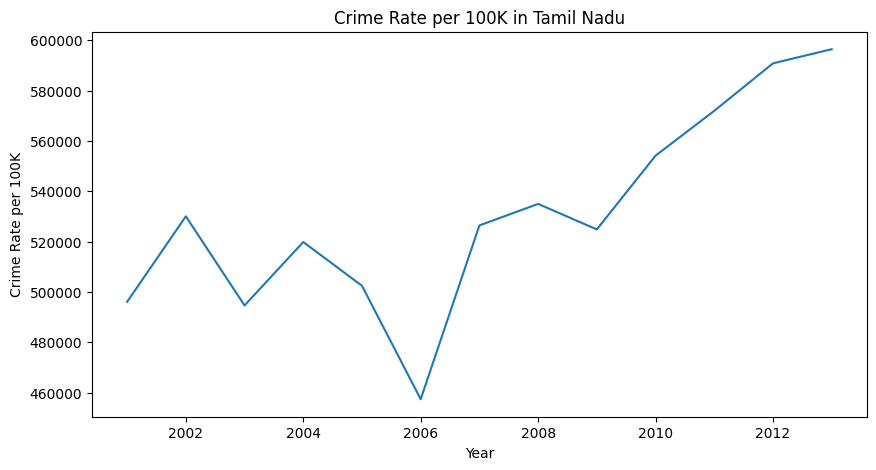

In [7]:
plt.figure(figsize=(10,5))
plt.plot(state_df["YEAR"], state_df["TOTAL_IPC_CRIMES(PER_100K)"])
plt.title(f"Crime Rate per 100K in {state}")
plt.xlabel("Year")
plt.ylabel("Crime Rate per 100K")
plt.show()

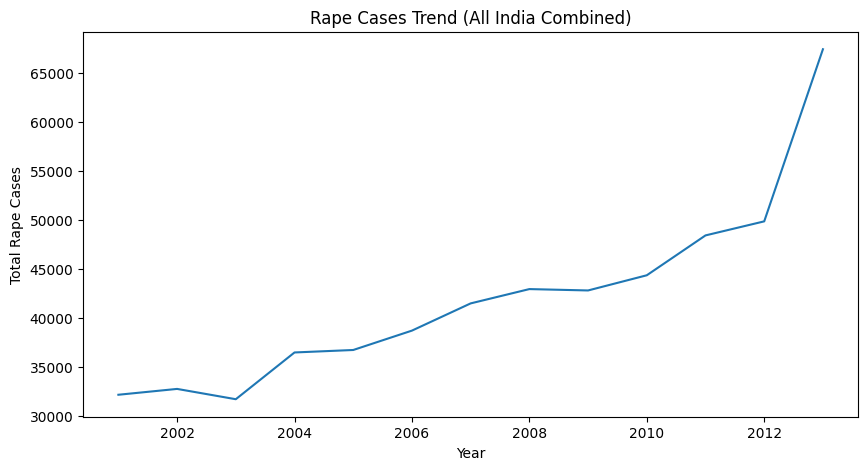

In [8]:
rape_yearly = df.groupby("YEAR")["RAPE"].sum()

plt.figure(figsize=(10,5))
plt.plot(rape_yearly.index, rape_yearly.values)
plt.title("Rape Cases Trend (All India Combined)")
plt.xlabel("Year")
plt.ylabel("Total Rape Cases")
plt.show()

In [9]:
safest_states = latest_df.sort_values(
    by="TOTAL_IPC_CRIMES(PER_100K)",
    ascending=True
).head(5)

safest_states[["STATE/UT", "TOTAL_IPC_CRIMES(PER_100K)"]]

,STATE/UT,TOTAL_IPC_CRIMES(PER_100K)
438,Lakshadweep,103896.1039
444,Nagaland,105693.1769
427,D&N Haveli,162273.9018
428,Daman & Diu,167918.0887
453,Uttarakhand,186737.0892


Serious Crimes

In our dataset, serious crimes include:

MURDER

RAPE

DOWRY DEATHS

KIDNAPPING & ABDUCTION

RIOTS

ROBBERY

These represent higher severity crimes under the Indian Penal Code.

In [10]:
# Select latest year for ranking
latest_year = df["YEAR"].max()
latest_df = df[df["YEAR"] == latest_year].copy()

# Calculate severity score using per 100k columns
latest_df["SEVERITY_SCORE"] = (
    latest_df["MURDER(PER_100K)"] * 5 +
    latest_df["RAPE(PER_100K)"] * 4 +
    latest_df["DOWRY_DEATHS(PER_100K)"] * 3 +
    latest_df["KIDNAPPING_&_ABDUCTION(PER_100K)"] * 3 +
    latest_df["RIOTS(PER_100K)"] * 2 +
    latest_df["ROBBERY(PER_100K)"] * 2
)

latest_df[["STATE/UT", "SEVERITY_SCORE"]].head()

,STATE/UT,SEVERITY_SCORE
420,A&N Islands,71153.846138
421,Andhra Pradesh,74450.590868
422,Arunachal Pradesh,203622.047208
423,Assam,230754.494088
424,Bihar,137357.038141


In [11]:
# Sort by severity score (descending)
ranked_states = latest_df.sort_values(
    by="SEVERITY_SCORE",
    ascending=False
)

ranked_states[["STATE/UT", "SEVERITY_SCORE"]].head(10)

,STATE/UT,SEVERITY_SCORE
429,Delhi UT,319104.920899
423,Assam,230754.494088
422,Arunachal Pradesh,203622.047208
432,Haryana,171666.793573
437,Kerala,166780.841459
425,Chandigarh,165569.620246
442,Meghalaya,160104.399696
426,Chhattisgarh,156979.405041
434,Jammu & Kashmir,147110.741031
435,Jharkhand,147003.154602


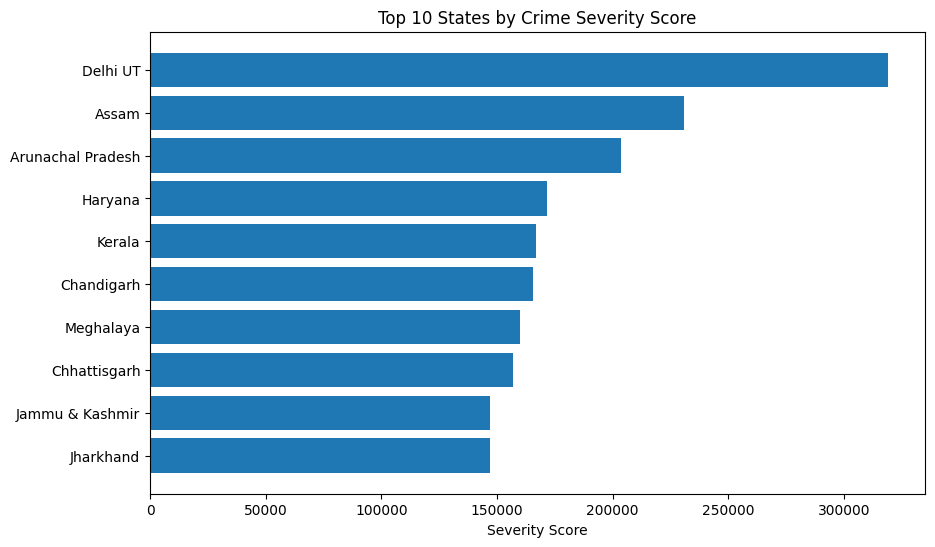

In [12]:
import matplotlib.pyplot as plt

top_10 = ranked_states.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10["STATE/UT"], top_10["SEVERITY_SCORE"])
plt.gca().invert_yaxis()
plt.title("Top 10 States by Crime Severity Score")
plt.xlabel("Severity Score")
plt.show()

Normalize Score

To improve the index further using Min-Max Scaling.

In [18]:
!pip install scikit-learn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [20]:
# Manual Min-Max Normalization

min_score = latest_df["SEVERITY_SCORE"].min()
max_score = latest_df["SEVERITY_SCORE"].max()

latest_df["NORMALIZED_SCORE"] = (
    (latest_df["SEVERITY_SCORE"] - min_score) /
    (max_score - min_score)
)

latest_df[["STATE/UT", "NORMALIZED_SCORE"]].head()

,STATE/UT,NORMALIZED_SCORE
420,A&N Islands,0.138868
421,Andhra Pradesh,0.150317
422,Arunachal Pradesh,0.598929
423,Assam,0.693160
424,Bihar,0.368791


In [21]:
def classify_safety(score):
    if score < 0.33:
        return "Safe"
    elif score < 0.66:
        return "Moderate"
    else:
        return "High Risk"

latest_df["SAFETY_LEVEL"] = latest_df["NORMALIZED_SCORE"].apply(classify_safety)

latest_df[["STATE/UT", "SAFETY_LEVEL"]].head(10)

,STATE/UT,SAFETY_LEVEL
420,A&N Islands,Safe
421,Andhra Pradesh,Safe
422,Arunachal Pradesh,Moderate
423,Assam,High Risk
424,Bihar,Moderate
425,Chandigarh,Moderate
426,Chhattisgarh,Moderate
427,D&N Haveli,Safe
428,Daman & Diu,Safe
429,Delhi UT,High Risk
